In [3]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 42.6M/42.6M [00:13<00:00, 3.39MB/s]

Extracting files...


Path to dataset files: C:\Users\salma\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [29]:
!pip install folium --upgrade


   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [35]:
# Standard libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib.gridspec import GridSpec
pd.set_option('display.max_columns', 100)
import plotly.offline as py
import plotly.express as px
import plotly.graph_objs as go
import matplotlib.colors as mcolors
import folium
from folium.plugins import FastMarkerCluster, Fullscreen, MiniMap, HeatMap, HeatMapWithTime, LocateControl
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

<a id="2"></a>
<font color="darkslateblue" size=+2.5><b>Reading the Data</b></font>

<a href="#top" class="btn btn-primary btn-sm" role="button" aria-pressed="true" style="color:white" data-toggle="popover">Go to TOC</a>

In [10]:
raw_path = 'C:/Users/salma/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/'
olist_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
olist_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
olist_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
olist_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
olist_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
olist_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
olist_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
olist_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')

<a id="2.1"></a>
<font color="dimgrey" size=+2.0><b>An Overview from the Data</b></font>

<a href="#top" class="btn btn-primary btn-sm" role="button" aria-pressed="true" style="color:white" data-toggle="popover">Go to TOC</a>

In [11]:
# Collections for each dataset
datasets = [olist_customer, olist_geolocation, olist_orders, olist_order_items, olist_order_payments,
            olist_order_reviews, olist_products, olist_sellers]
names = ['olist_customer', 'olist_geolocation', 'olist_orders', 'olist_order_items', 'olist_order_payments',
         'olist_order_reviews', 'olist_products', 'olist_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names  # the 8 dataset names 
data_info['n_rows'] = [df.shape[0] for df in datasets] # loops over each dataset and gives off the number of rows so 8
data_info['n_cols'] = [df.shape[1] for df in datasets] # loops over each dataset again and gives off the number of each column so 8 too
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets] # calculate the number of null values for every data set so 8 too
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

# selected the columns with null values and counted them for each data set so 8 too
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

# this one appends them together into a string using join  8 too

data_info.style.background_gradient()

,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,olist_customer,99441,5,0,0,
1,olist_geolocation,1000163,5,0,0,
2,olist_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,olist_order_items,112650,7,0,0,
4,olist_order_payments,103886,5,0,0,
5,olist_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,olist_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,olist_sellers,3095,4,0,0,


### Initial Observations

- The **Geolocation** table is the largest table in the dataset, containing approximately **100,000 records**.
- The **Orders** table contains missing values in three timestamp columns: `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date`. These missing values are expected, as not all orders progress through every stage of the order fulfillment process (e.g., canceled or unavailable orders).
- The **Order_Reviews** table contains the highest number of missing values, primarily in `review_comment_title` and `review_comment_message`. This is expected because customers can submit a review score without leaving an optional title or written comment.

In [16]:

def data_overview(df):
    overview = pd.DataFrame({
        'feature': df.columns,
        'qtd_null': df.isnull().sum().values,
        'percent_null': (df.isnull().sum() / df.shape[0]).values,
        'dtype': df.dtypes.values
    })
    
    # qtd_cat = number of unique values, but only for object (categorical) columns
    overview['qtd_cat'] = overview['feature'].apply(
        lambda col: df[col].nunique() if df[col].dtype == 'object' else 0
    )
    
    return overview

In [18]:
df_overview = pd.DataFrame({})  # our empty dataset
name_col = []  # empty list
for name, df in zip(names, datasets):
    name_col += [name] * df.shape[1]
    df_overview = pd.concat([df_overview, data_overview(df)])  # <-- changed here
    df_overview['dataset_name'] = name_col

df_overview = df_overview.loc[:, ['dataset_name', 'feature', 'qtd_null', 'percent_null', 'dtype', 'qtd_cat']]

In [19]:
df_overview

,dataset_name,feature,qtd_null,percent_null,dtype,qtd_cat
0,olist_customer,customer_id,0,0.000000,object,99441
1,olist_customer,customer_unique_id,0,0.000000,object,96096
2,olist_customer,customer_zip_code_prefix,0,0.000000,int64,0
3,olist_customer,customer_city,0,0.000000,object,4119
4,olist_customer,customer_state,0,0.000000,object,27
0,olist_geolocation,geolocation_zip_code_prefix,0,0.000000,int64,0
1,olist_geolocation,geolocation_lat,0,0.000000,float64,0
2,olist_geolocation,geolocation_lng,0,0.000000,float64,0
3,olist_geolocation,geolocation_city,0,0.000000,object,8011
4,olist_geolocation,geolocation_state,0,0.000000,object,27




### Data Type Conversion

Several columns containing dates and timestamps are currently stored as strings (`object`). These columns need to be converted to the `datetime` data type to enable time-based analysis and feature engineering.

The columns to be converted are:

- `order_purchase_timestamp`
- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `shipping_limit_date`
- `review_creation_date`
- `review_answer_timestamp`
- `order_estimated_delivery_date`

### Categorical Columns

Columns representing categorical information are currently stored as the `object` data type. Converting these columns to the `category` data type reduces memory usage and can improve the performance of certain operations.

### Handling Missing Values

The dataset also contains missing values across several columns. Before proceeding with the analysis, these missing values will be identified and handled appropriately based on the context of each feature. Depending on the column, missing values may be left as they are, imputed, or removed if necessary.

<a id="3"></a>
<font color="darkslateblue" size=+3><b>Exploratory Data Analysis</b></font>

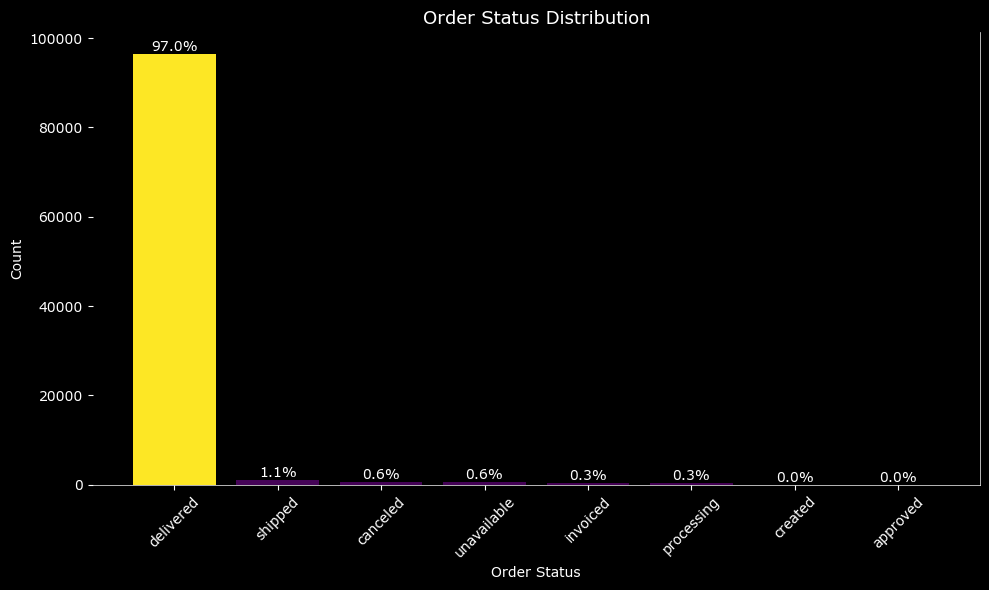

In [25]:

# Set font globally
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Verdana']  # change to your preferred font

status_counts = df_orders['order_status'].value_counts()
status_pct = df_orders['order_status'].value_counts(normalize=True) * 100

norm = mcolors.Normalize(vmin=status_counts.min(), vmax=status_counts.max())
cmap = plt.get_cmap('viridis')
colors = [cmap(norm(val)) for val in status_counts.values]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

bars = ax.bar(status_counts.index, status_counts.values, color=colors)

for bar, pct in zip(bars, status_pct):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=10, color='white')

ax.set_title('Order Status Distribution', color='white', fontsize=13)
ax.set_xlabel('Order Status', color='white')
ax.set_ylabel('Count', color='white')
ax.tick_params(colors='white')

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_color('white')
ax.spines['right'].set_linewidth(0.5)
ax.spines['bottom'].set_color('white')
ax.spines['bottom'].set_linewidth(0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Order Status Distribution

The vast majority of orders in the dataset were successfully completed. Approximately **97%** of all orders have a status of **Delivered**, indicating that the dataset primarily consists of completed transactions. The remaining **3%** are distributed among statuses such as *Shipped*, *Canceled*, *Unavailable*, *Invoiced*, *Processing*, and *Created*.

In [26]:
# Changing the data type for date columns
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
                  'order_estimated_delivery_date']
for col in timestamp_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])
    
# Extracting attributes for purchase date - Year and Month
df_orders['order_purchase_year'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.year)
df_orders['order_purchase_month'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.month)
df_orders['order_purchase_month_name'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.strftime('%b'))
df_orders['order_purchase_year_month'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.strftime('%Y%m'))
df_orders['order_purchase_date'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.strftime('%Y%m%d'))

# Extracting attributes for purchase date - Day and Day of Week
df_orders['order_purchase_day'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.day)
df_orders['order_purchase_dayofweek'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.dayofweek)
df_orders['order_purchase_dayofweek_name'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.strftime('%a'))

# Extracting attributes for purchase date - Hour and Time of the Day
df_orders['order_purchase_hour'] = df_orders['order_purchase_timestamp'].apply(lambda x: x.hour)
hours_bins = [-0.1, 6, 12, 18, 23]
hours_labels = ['Dawn', 'Morning', 'Afternoon', 'Night']
df_orders['order_purchase_time_day'] = pd.cut(df_orders['order_purchase_hour'], hours_bins, labels=hours_labels)

# New DataFrame after transformations
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_purchase_year,order_purchase_month,order_purchase_month_name,order_purchase_year_month,order_purchase_date,order_purchase_day,order_purchase_dayofweek,order_purchase_dayofweek_name,order_purchase_hour,order_purchase_time_day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017,10,Oct,201710,20171002,2,0,Mon,10,Morning
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018,7,Jul,201807,20180724,24,1,Tue,20,Night
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018,8,Aug,201808,20180808,8,2,Wed,8,Morning
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017,11,Nov,201711,20171118,18,5,Sat,19,Night
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018,2,Feb,201802,20180213,13,1,Tue,21,Night


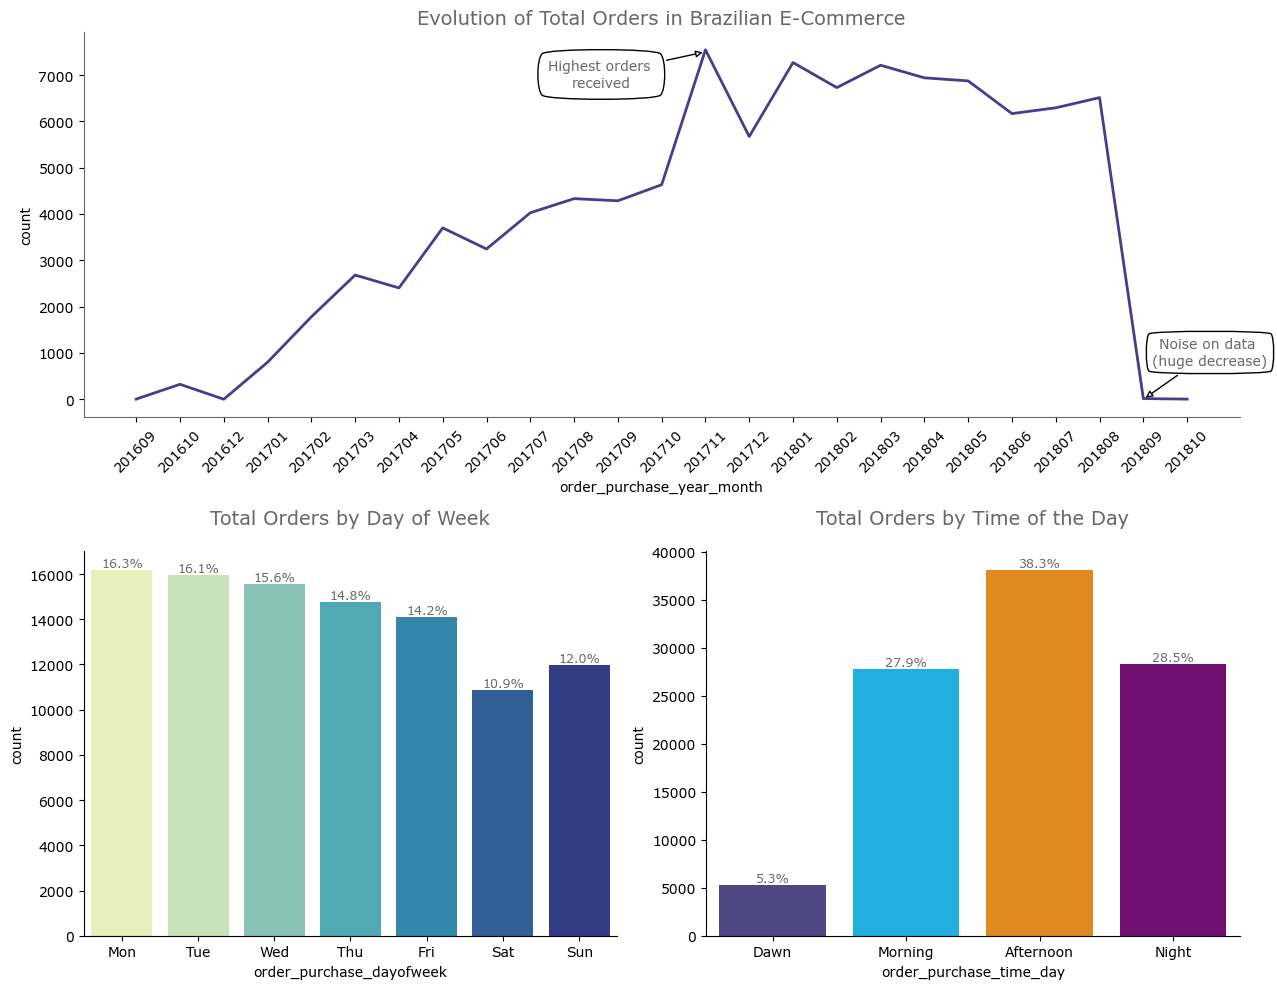

In [36]:

fig = plt.figure(constrained_layout=True, figsize=(13, 10))

# Axis definition
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# ---- Lineplot - Evolution of e-commerce orders along time ----
sns.lineplot(data=df_orders['order_purchase_year_month'].value_counts().sort_index(), ax=ax1,
             color='darkslateblue', linewidth=2)

ax1.annotate(f'Highest orders \nreceived', (13, 7500), xytext=(-75, -25),
             textcoords='offset points', bbox=dict(boxstyle="round4", fc="w", pad=.8),
             arrowprops=dict(arrowstyle='-|>', fc='w'), color='dimgrey', ha='center')
ax1.annotate(f'Noise on data \n(huge decrease)', (23, 0), xytext=(48, 25),
             textcoords='offset points', bbox=dict(boxstyle="round4", fc="w", pad=.5),
             arrowprops=dict(arrowstyle='-|>', fc='w'), color='dimgrey', ha='center')

# Replaces format_spines(ax1, right_border=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('dimgrey')
ax1.spines['bottom'].set_color('dimgrey')

for tick in ax1.get_xticklabels():
    tick.set_rotation(45)
ax1.set_title('Evolution of Total Orders in Brazilian E-Commerce', size=14, color='dimgrey')

# ---- Barchart - Total of orders by day of week ----
weekday_label = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Replaces single_countplot(df_orders, x='order_purchase_dayofweek', ax=ax2, order=False, palette='YlGnBu')
sns.countplot(data=df_orders, x='order_purchase_dayofweek', ax=ax2, palette='YlGnBu')

# Add percentage annotations above each bar
total_ax2 = len(df_orders)
for p in ax2.patches:
    pct = (p.get_height() / total_ax2) * 100
    ax2.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=9, color='dimgrey')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticklabels(weekday_label)
ax2.set_title('Total Orders by Day of Week', size=14, color='dimgrey', pad=20)

# ---- Barchart - Total of orders by time of the day ----
day_color_list = ['darkslateblue', 'deepskyblue', 'darkorange', 'purple']

# Replaces single_countplot(df_orders, x='order_purchase_time_day', ax=ax3, order=False, palette=day_color_list)
sns.countplot(data=df_orders, x='order_purchase_time_day', ax=ax3, palette=day_color_list)

total_ax3 = len(df_orders)
for p in ax3.patches:
    pct = (p.get_height() / total_ax3) * 100
    ax3.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=9, color='dimgrey')

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_title('Total Orders by Time of the Day', size=14, color='dimgrey', pad=20)

plt.tight_layout()
plt.show()

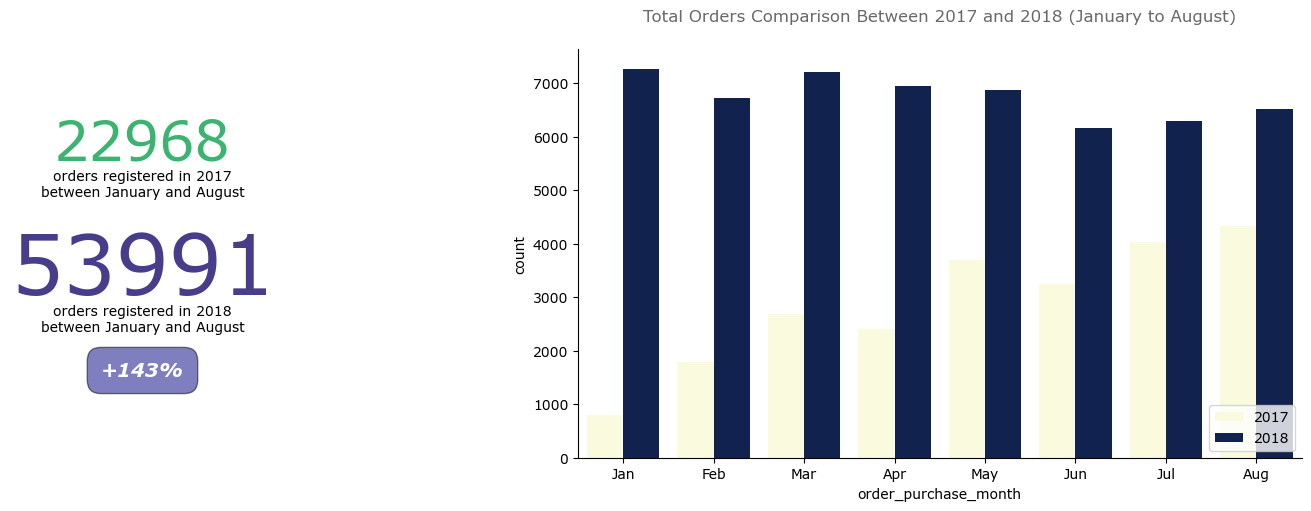

In [38]:

# Creating figure
fig = plt.figure(constrained_layout=True, figsize=(13, 5))

# Axis definition
gs = GridSpec(1, 3, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1:])

# ---- Annotation - Growth on e-commerce orders between 2017 and 2018 ----
df_orders_compare = df_orders.query('order_purchase_year in (2017, 2018) & order_purchase_month <= 8')
year_orders = df_orders_compare['order_purchase_year'].value_counts()
growth = int(round(100 * (1 + year_orders[2017] / year_orders[2018]), 0))

ax1.text(0.00, 0.73, f'{year_orders[2017]}', fontsize=40, color='mediumseagreen', ha='center')
ax1.text(0.00, 0.64, 'orders registered in 2017\nbetween January and August', fontsize=10, ha='center')
ax1.text(0.00, 0.40, f'{year_orders[2018]}', fontsize=60, color='darkslateblue', ha='center')
ax1.text(0.00, 0.31, 'orders registered in 2018\nbetween January and August', fontsize=10, ha='center')

signal = '+' if growth > 0 else '-'
ax1.text(0.00, 0.20, f'{signal}{growth}%', fontsize=14, ha='center', color='white', style='italic', weight='bold',
         bbox=dict(facecolor='navy', alpha=0.5, pad=10, boxstyle='round, pad=.7'))
ax1.axis('off')

# ---- Bar chart - Comparison between monthly sales between 2017 and 2018 ----
# Replaces single_countplot(df_orders_compare, x='order_purchase_month', hue='order_purchase_year', ax=ax2, order=False, palette='YlGnBu')
sns.countplot(data=df_orders_compare, x='order_purchase_month', hue='order_purchase_year', ax=ax2, palette='YlGnBu')

month_label = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
ax2.set_xticklabels(month_label)
ax2.set_title('Total Orders Comparison Between 2017 and 2018 (January to August)', size=12, color='dimgrey', pad=20)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.legend(loc='lower right')
plt.show()